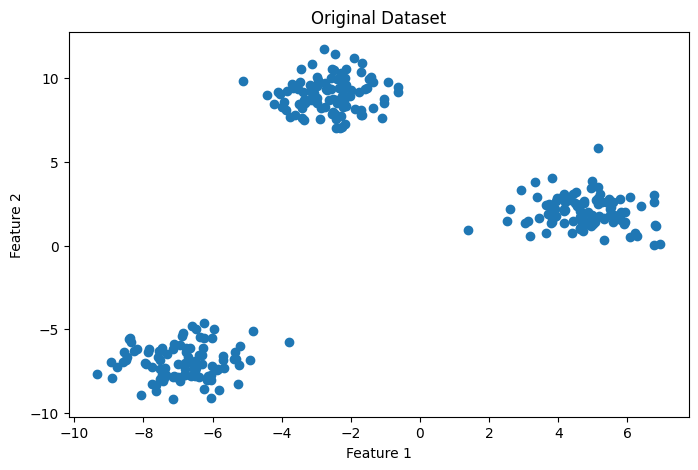

Initial Centroids:
[[-7.33898809 -7.72995396]
 [-2.77385446 11.73445529]
 [ 6.9545374   0.10590449]]


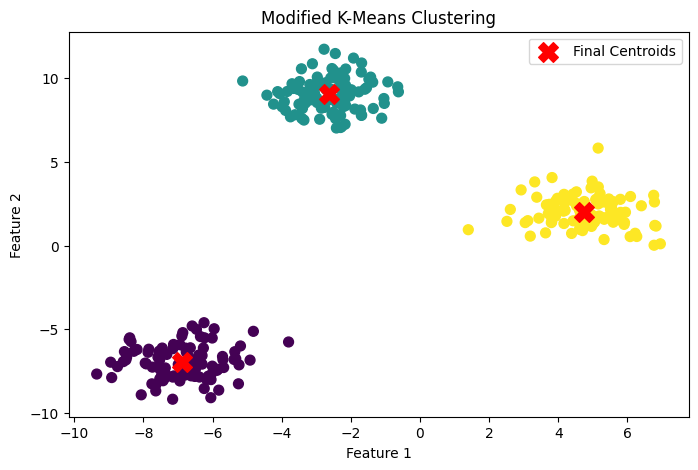


Evaluation Results
-------------------------
Number of Clusters: 3
Inertia: 566.8595511244134
Silhouette Score: 0.8480303059596955
Cluster 0: 100 data points
Cluster 1: 100 data points
Cluster 2: 100 data points


In [1]:
# ==========================================
# Experiment 2: Modified K-Means Clustering
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# 1. Generate dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)


# 2. Visualize original dataset
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 3. Modified Centroid Initialization
# ==========================================

def modified_initialization(X, k):

    # Select the first centroid
    centroids = [X[0]]

    for _ in range(1, k):

        # Calculate distance of every point
        # from the nearest selected centroid
        distances = np.array([
            min(np.linalg.norm(x - c) for c in centroids)
            for x in X
        ])

        # Select the point with maximum distance
        next_centroid = X[np.argmax(distances)]

        centroids.append(next_centroid)

    return np.array(centroids)


# 4. Set number of clusters
k = 3


# 5. Select initial centroids using
#    Modified K-Means method
initial_centroids = modified_initialization(X, k)

print("Initial Centroids:")
print(initial_centroids)


# ==========================================
# 6. Apply K-Means using selected centroids
# ==========================================

kmeans_modified = KMeans(
    n_clusters=k,
    init=initial_centroids,
    n_init=1,
    random_state=42
)

labels = kmeans_modified.fit_predict(X)


# 7. Get final centroids
final_centroids = kmeans_modified.cluster_centers_


# ==========================================
# 8. Visualize Modified K-Means Clusters
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=50
)

plt.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Final Centroids"
)

plt.title("Modified K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


# ==========================================
# 9. Evaluation
# ==========================================

inertia = kmeans_modified.inertia_

silhouette = silhouette_score(
    X,
    labels
)

print("\nEvaluation Results")
print("-------------------------")
print("Number of Clusters:", k)
print("Inertia:", inertia)
print("Silhouette Score:", silhouette)


# 10. Cluster sizes

for i in range(k):
    print(
        f"Cluster {i}: {np.sum(labels == i)} data points"
    )